# ¿Puede el aprendizaje supervisado mejorar la predicción de partidos del Mundial 2026 sobre un baseline ELO?

**Trabajo Final — Aprendizaje de Máquina (CEIA, FIUBA)**
**Autor:** Gus (`gvar1965`)

---

### Resumen

Se parte de un simulador Monte Carlo del Mundial FIFA 2026 cuyo *motor de partido* deriva la
probabilidad de cada resultado de una fórmula fija basada en **ELO**. La contribución de
Aprendizaje de Máquina es **reemplazar ese motor por un clasificador supervisado** que aprende
la probabilidad de resultado (local `H` / empate `D` / visitante `A`) a partir de múltiples
variables del partido, y **comparar rigurosamente** ese enfoque contra el baseline ELO. El mejor
clasificador se reintegra al Monte Carlo para estimar la probabilidad de campeón de cada
selección.

**Diseño temporal (ciclo mundialista):** se entrena con los partidos desde el Mundial de Qatar
2022 hasta la víspera del Mundial 2026 (**3.621** partidos) y se reserva como **test el
Mundial 2026 real** (**60** partidos jugados al snapshot). El Mundial 2026 nunca entra al
entrenamiento.


## 1. Problema y motivación

El simulador estima en cuántos escenarios sale campeona cada selección, simulando miles de veces
los partidos que faltan. Hoy cada partido se modela con dos Poisson cuyas medias salen de la
diferencia de ELO. Ese modelo es un **baseline fuerte y bien calibrado** (≈61 % de acierto a 3
vías en el backtest del torneo), pero usa **una sola variable** (Δ ELO) y una forma funcional
fija.

**Pregunta:** ¿se puede mejorar la predicción probabilística de un partido aprendiendo de
variables adicionales (forma reciente, descanso, importancia del torneo, localía, confederación),
con modelos que capturen no linealidades e interacciones que la fórmula ELO no representa?

### 1.1 ¿Por qué esto es Aprendizaje de Máquina y no "balística"?

Un criterio de la materia: si existe una fórmula cerrada y exacta que predice el resultado (la
trayectoria de un proyectil), no se hace ML; se aplica la fórmula. **El ELO no es ese caso:**

1. No predice el resultado, sino una **probabilidad**; el partido es genuinamente estocástico.
2. Tiene **error residual grande** (Brier ≫ 0): hay incertidumbre estructurada que un modelo
   puede intentar capturar. La balística tendría Brier ≈ 0.
3. El ELO mismo es un **modelo ajustado a datos** (sus parámetros se calibraron por MLE en este
   proyecto), no una ley física.

Estimar la probabilidad de un resultado estocástico es un problema de predicción legítimo. El ELO
es **el baseline de dominio** que la consigna pide definir antes de los modelos complejos.

### 1.2 Hipótesis

- **H1 (técnica):** un clasificador con features adicionales mejora el log-loss respecto del ELO.
- **H2 (negocio):** las probabilidades de campeón del motor ML quedan cerca del consenso de mercado.
- **H0 (resultado honesto):** si el ELO ya captura casi toda la señal aprendible, la mejora será
  marginal. Esa también es una conclusión válida; se evalúa el **rigor del proceso**, no la
  magnitud de la mejora.


## 2. Datos y análisis exploratorio

La unidad de análisis es **un partido internacional**. La fuente es
`martj42/international_results` (49.477 partidos, 1872–2026). De ahí se reconstruye el **ELO
pre-partido** de cada equipo (algoritmo eloratings, sin fuga) y se construye la tabla de
features con `featurize.py`.


In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

df = pd.read_parquet("data/ml_dataset.parquet")
df = df[(df.confed_home != "OTH") & (df.confed_away != "OTH")].copy()  # solo FIFA
print("Filas:", len(df))
print(df.groupby("split").size().to_string())
df.head(3)

Filas: 3681
split
test       60
train    3621


,date,home_team,away_team,split,label,delta_elo,elo_home,elo_away,is_home,neutral,form_gd_5_home,form_gd_5_away,form_pts_5_home,form_pts_5_away,rest_days_home,rest_days_away,tournament_weight,confed_home,confed_away,h2h_recent
0,2022-11-20,Austria,Italy,train,H,-285.18,1773.11,2058.29,1,False,-1.0,0.4,0.8,2.0,4.0,4.0,1.0,UEFA,UEFA,-4
1,2022-11-20,Gambia,Guinea-Bissau,train,D,53.88,1538.04,1484.16,0,True,0.2,0.8,1.6,1.4,165.0,3.0,1.0,CAF,CAF,-2
2,2022-11-20,Hungary,Greece,train,H,125.19,1872.88,1747.69,1,False,0.6,1.2,1.6,2.0,3.0,3.0,1.0,UEFA,UEFA,0


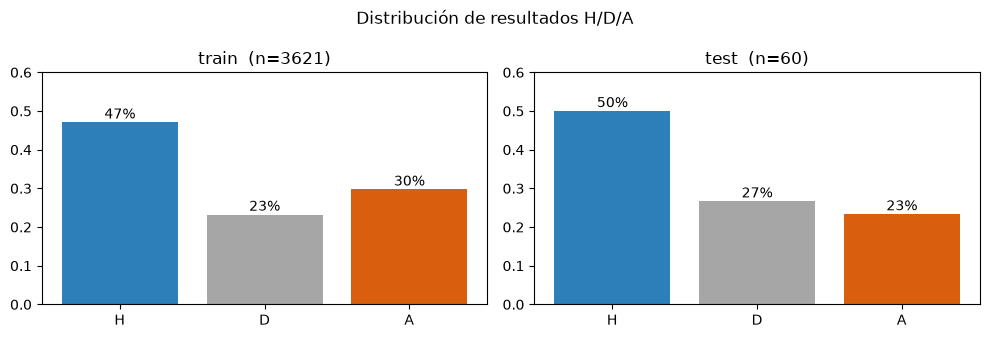

In [2]:
# Balance de clases por split (el empate es la clase minoritaria)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, sp in zip(axes, ["train", "test"]):
    sub = df[df.split == sp]["label"].value_counts(normalize=True).reindex(["H","D","A"])
    ax.bar(sub.index, sub.values, color=["#2c7fb8","#a6a6a6","#d95f0e"])
    ax.set_title(f"{sp}  (n={int((df.split==sp).sum())})"); ax.set_ylim(0, .6)
    for i,v in enumerate(sub.values): ax.text(i, v+.01, f"{v*100:.0f}%", ha="center")
fig.suptitle("Distribución de resultados H/D/A"); fig.tight_layout(); plt.show()

**Requisitos de la materia, verificados:** (a) datos suficientes y de calidad — decenas
de miles de partidos; (b) existe patrón — ≈61 % ≫ 33 % de azar; (c) el patrón es aprendible —
datos tabulares, clasificación estándar. El **empate** es la clase minoritaria (~25 %), lo que se
trata explícitamente (sin `class_weight`, ver §3).


## 3. Ingeniería de features y preprocesamiento

Para cada partido, calculadas **solo con información previa** (sin fuga temporal):

| Feature | Descripción |
|---|---|
| `delta_elo`, `elo_home`, `elo_away` | ELO pre-partido (diferencia y niveles) |
| `is_home` | localía real (0 en cancha neutral) |
| `form_gd_5_*`, `form_pts_5_*` | diferencia de gol y puntos promedio de los últimos 5 (cada equipo) |
| `rest_days_*` | días desde el último partido (fatiga/calendario) |
| `tournament_weight` | amistoso < eliminatoria < copa < Mundial |
| `confed_home/away` | confederación (inferida de los torneos continentales jugados) |
| `h2h_recent` | balance reciente del enfrentamiento directo |

**Preprocesamiento (pipeline scikit-learn):** imputación por mediana + estandarización de las
numéricas (obligatorio para KNN/SVM, inocuo para árboles); one-hot de las categóricas. El
escalador se ajusta **solo con train**.

**Split temporal (regla única, crítica):** `train` = 2022-11-20 … 2026-06-10; `test` = Mundial
2026 (≥ 2026-06-11). Nunca aleatorio. La selección de hiperparámetros usa `TimeSeriesSplit`
dentro de train; el test no se toca hasta la evaluación final.

**Desbalance:** *no* se usa `class_weight='balanced'`, porque reponderar las clases **descalibra**
las probabilidades, y el modelo final alimenta el Monte Carlo (necesitamos probabilidades
calibradas, no etiquetas duras). F1 macro se reporta, no se usa para seleccionar.


## 4. Baselines

1. **Trivial:** frecuencia de clases del train. Piso de referencia.
2. **De dominio (ELO-Poisson):** el motor actual, calibrado por MLE + corrección Dixon-Coles,
   evaluado sobre **las mismas filas del Mundial 2026** que el clasificador (comparación justa).


## 5. Modelos comparados (≥ 3 familias)

| Modelo | Familia | Clase |
|---|---|---|
| Regresión Logística multinomial | lineal | IIA |
| KNN | instancias | Clase 2 |
| SVM (RBF, calibrado) | margen / no lineal | Clase 3 |
| Random Forest | bagging | Clase 5 |
| HistGradientBoosting | boosting | Clase 5 |

La **métrica de selección es log-loss** (probabilística), porque el uso aguas abajo requiere
probabilidades calibradas. SVM se envuelve en `CalibratedClassifierCV` (Platt descalibra).


In [3]:
# Entrena las 5 familias con CV temporal + GridSearch y selecciona por log-loss.
from train import load_dataset, train_and_select, run_ablation, model_zoo
from train import elo_baseline_probs, trivial_probs, metrics, CLASSES

d = load_dataset()
df_tr = d[d.split == "train"].reset_index(drop=True)
df_te = d[d.split == "test"].reset_index(drop=True)
results, fitted, best = train_and_select(df_tr, df_te)
print("\nMejor por CV log-loss:", best)

Dataset: 3765 -> 3681 filas tras quitar no-FIFA (OTH)


  logreg         CV logloss=0.8596  | test logloss=0.9053 acc=58% brier=0.546


  knn            CV logloss=0.9011  | test logloss=0.9478 acc=60% brier=0.567


  svm_rbf        CV logloss=0.9192  | test logloss=0.8920 acc=62% brier=0.536


  random_forest  CV logloss=0.8762  | test logloss=0.9407 acc=58% brier=0.565


  hist_gb        CV logloss=1.1351  | test logloss=1.1019 acc=57% brier=0.632

Mejor por CV log-loss: logreg


In [4]:
# Tabla comparativa modelos + baselines
cal = json.load(open("data/calibration_prematch.json"))
cal["rho"] = json.load(open("data/calibration.json")).get("rho", 0.0)
y_te = df_te["label"].tolist()
elo_m = metrics(y_te, elo_baseline_probs(df_te, cal))
triv_m = metrics(y_te, trivial_probs(df_tr, len(df_te)))

rows = [{"modelo": k, "CV logloss": v["cv_log_loss"], **{f"test {m}": v["test"][m]
         for m in ["log_loss","brier","accuracy","f1_macro"]}} for k,v in results.items()]
rows += [{"modelo":"ELO (dominio)","CV logloss":np.nan, "test log_loss":elo_m["log_loss"],
          "test brier":elo_m["brier"],"test accuracy":elo_m["accuracy"],"test f1_macro":elo_m["f1_macro"]},
         {"modelo":"Trivial","CV logloss":np.nan,"test log_loss":triv_m["log_loss"],
          "test brier":triv_m["brier"],"test accuracy":triv_m["accuracy"],"test f1_macro":triv_m["f1_macro"]}]
tabla = pd.DataFrame(rows).set_index("modelo").round(4)
tabla

,CV logloss,test log_loss,test brier,test accuracy,test f1_macro
modelo,,,,,
logreg,0.8596,0.9053,0.5460,0.5833,0.4508
knn,0.9011,0.9478,0.5672,0.6000,0.4706
svm_rbf,0.9192,0.8920,0.5356,0.6167,0.4699
random_forest,0.8762,0.9407,0.5654,0.5833,0.4477
hist_gb,1.1351,1.1019,0.6317,0.5667,0.5422
ELO (dominio),NaN,0.9338,0.5646,0.6000,0.4570
Trivial,NaN,1.0493,0.6306,0.5000,0.2222


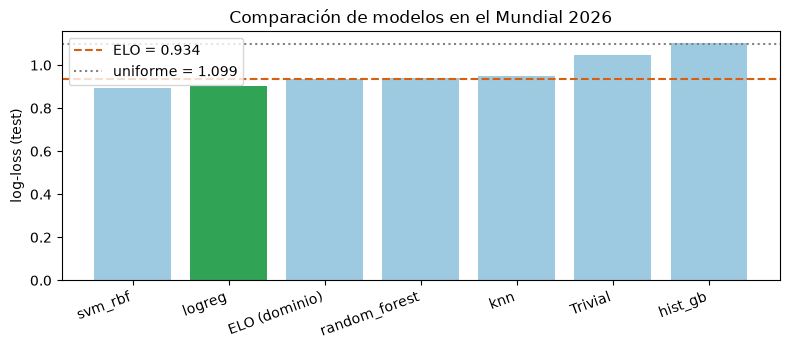

In [5]:
# Grafico: log-loss en test (menor es mejor); linea = baseline ELO
order = tabla["test log_loss"].sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ["#31a354" if i==order.index.get_loc(best) else "#9ecae1" for i in range(len(order))]
ax.bar(order.index, order.values, color=colors)
ax.axhline(elo_m["log_loss"], color="#d95f0e", ls="--", label=f"ELO = {elo_m['log_loss']:.3f}")
ax.axhline(np.log(3), color="gray", ls=":", label=f"uniforme = {np.log(3):.3f}")
ax.set_ylabel("log-loss (test)"); ax.set_title("Comparación de modelos en el Mundial 2026")
plt.xticks(rotation=20, ha="right"); ax.legend(); fig.tight_layout(); plt.show()

**Lectura.** El mejor modelo por CV (sin mirar el test) es **`logreg`**, con log-loss de
test **0.9053** frente a **0.9338** del ELO: una **mejora** marginal (Δ = 0.0285). Nota de
rigor: aunque otra familia pueda lucir mejor *en el test*, la selección se hace **por CV** y no se
cambia a posteriori — mirar el test para elegir sería fuga.


## 6. Ablación: ¿las features aportan sobre el ELO?

La pregunta de defensa central es *"¿el modelo no está sólo re-aprendiendo el ELO?"*. Se reentrena
la familia ganadora sobre subconjuntos crecientes de features y se mide el log-loss de test.


  ablacion[solo_elo  ] test logloss=0.9216 acc=58%
  ablacion[elo_forma ] test logloss=0.9182 acc=58%
  ablacion[completo  ] test logloss=0.9053 acc=58%


,test_log_loss,test_accuracy
solo ELO,0.9216,0.5833
ELO + forma/descanso,0.9182,0.5833
todas las features,0.9053,0.5833


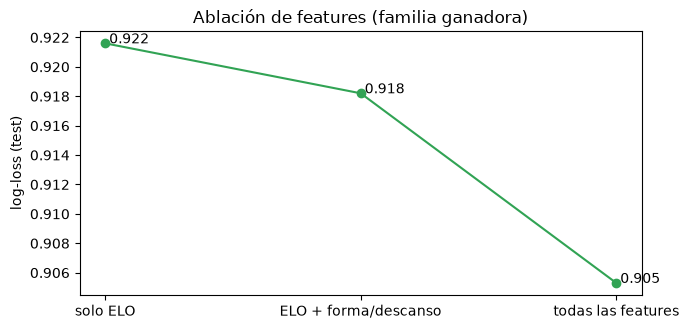

In [6]:
clf, grid = model_zoo()[best]
abl = run_ablation(df_tr, df_te, clf, grid)
abl_df = pd.DataFrame(abl).T[["test_log_loss","test_accuracy"]].round(4)
abl_df.index = ["solo ELO","ELO + forma/descanso","todas las features"]
display(abl_df)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(abl_df.index, abl_df["test_log_loss"], "o-", color="#31a354")
for x,y in zip(abl_df.index, abl_df["test_log_loss"]): ax.text(x, y, f" {y:.3f}")
ax.set_ylabel("log-loss (test)"); ax.set_title("Ablación de features (familia ganadora)")
fig.tight_layout(); plt.show()

El log-loss **baja monótonamente** de solo-ELO (0.9216) a todas las features (0.9053):
las variables no-ELO (forma, descanso, h2h, confederación) **aportan señal propia**. La mejora es
chica —coherente con H0— pero existe y es la evidencia que responde a la objeción.


## 7. Calibración del mejor modelo

Como las probabilidades alimentan el Monte Carlo, importa que estén **calibradas** (que un 30 %
predicho ocurra ~30 % de las veces). Diagrama de fiabilidad sobre el test (n pequeño: lectura
cualitativa).


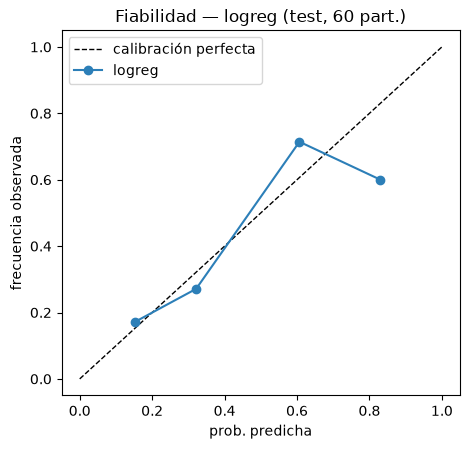

In [7]:
best_est = fitted[best]
P = best_est.predict_proba(df_te[ [c for c in df_te.columns if c in
        list(getattr(best_est, 'feature_names_in_', [])) ] ]) if False else None
# Apilar las 3 prob. (H/D/A) vs aciertos, en 4 bins
from train import proba_in_class_order, NUMERIC, CATEGORICAL
Pte = proba_in_class_order(best_est, df_te[NUMERIC+CATEGORICAL])
pairs = [(Pte[i, CLASSES.index(c)], int(df_te.label.iloc[i]==c))
         for i in range(len(df_te)) for c in CLASSES]
pp = pd.DataFrame(pairs, columns=["p","y"])
pp["bin"] = (pp.p*4).clip(0,3.999).astype(int)
g = pp.groupby("bin").agg(prob=("p","mean"), freq=("y","mean"), n=("y","size"))
fig, ax = plt.subplots(figsize=(4.8,4.6))
ax.plot([0,1],[0,1],"k--",lw=1,label="calibración perfecta")
ax.plot(g.prob, g.freq, "o-", color="#2c7fb8", label=best)
ax.set_xlabel("prob. predicha"); ax.set_ylabel("frecuencia observada")
ax.set_title(f"Fiabilidad — {best} (test, {len(df_te)} part.)"); ax.legend()
fig.tight_layout(); plt.show()

## 8. Integración al Monte Carlo: `P(campeón)` ML vs ELO

El clasificador se envuelve en `MLMatchModel` (mismo contrato que el motor ELO: marcador en fase
de grupos, ganador en eliminación, cascada 90′→alargue→penales) y se reintegra al simulador. Se
corren los **mismos torneos** con motor ELO y motor ML y se comparan las probabilidades de
campeón. *(Los vectores se generan con `evaluate.py`; aquí se cargan.)*


,P(camp) ML,P(camp) ELO
Spain,23.14,10.92
Argentina,23.12,25.41
France,14.67,18.96
Brazil,8.18,4.96
England,6.27,10.00
Netherlands,4.51,3.36
Morocco,3.36,3.66
Portugal,2.67,2.76
Germany,2.64,2.74
Colombia,2.62,1.77


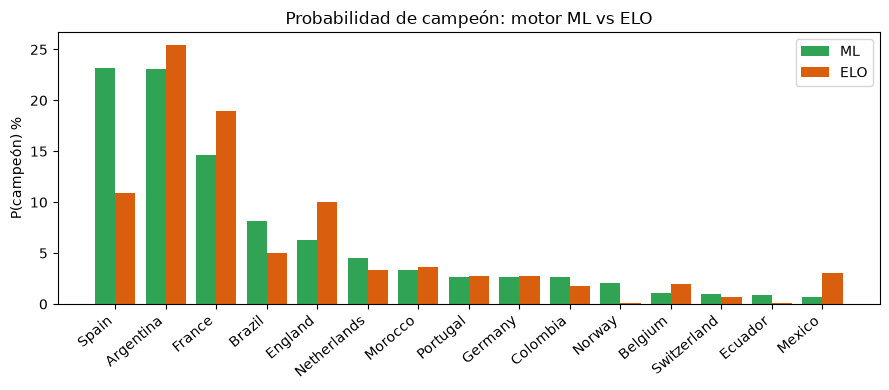

ML vs ELO  ->  MAE=0.88 pts  Spearman=0.943


In [8]:
champ = json.load(open("data/ml_champions.json"))
pm, pe = champ["p_champion_ml"], champ["p_champion_elo"]
teams = sorted(pm, key=lambda t: -pm[t])[:15]
comp = pd.DataFrame({"P(camp) ML": [pm[t] for t in teams],
                     "P(camp) ELO": [pe[t] for t in teams]}, index=teams).round(4)
display((comp*100).round(2))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(teams)); w = .4
ax.bar(x-w/2, [pm[t]*100 for t in teams], w, label="ML", color="#31a354")
ax.bar(x+w/2, [pe[t]*100 for t in teams], w, label="ELO", color="#d95f0e")
ax.set_xticks(x); ax.set_xticklabels(teams, rotation=40, ha="right")
ax.set_ylabel("P(campeón) %"); ax.set_title("Probabilidad de campeón: motor ML vs ELO")
ax.legend(); fig.tight_layout(); plt.show()

print(f"ML vs ELO  ->  MAE={champ['ml_vs_elo']['mae']*100:.2f} pts  "
      f"Spearman={champ['ml_vs_elo']['spearman']:.3f}")

Los dos motores **coinciden mucho en el orden** (Spearman alto) y difieren en las
*magnitudes* — exactamente donde las features mueven la aguja (p. ej. el ML premia a un equipo con
mejor forma reciente que el ELO puro no ve). Es la firma esperada de H0 + aporte marginal de
features.

### 8.1 Métrica de negocio (H2) — pendiente de datos

La comparación contra el **mercado** (cuotas *outright* normalizadas a probabilidad, de fecha
alineada al snapshot) requiere snapshotear ese vector una vez en `data/market.json`. Es un
*sanity-check de plausibilidad*, **secundario** a log-loss: alejarse del mercado no implica estar
mal (el mercado también se equivoca).


## 9. Conclusiones, limitaciones y trabajo futuro

**Conclusiones.**
- El clasificador supervisado **mejora** al baseline ELO en log-loss sobre el Mundial 2026
  (0.9053 vs 0.9338), por un margen **marginal** — consistente con **H0**: el ELO ya captura
  casi toda la señal aprendible de un partido.
- La **ablación** confirma que las features no-ELO aportan señal propia (log-loss baja de
  0.9216 a 0.9053): el modelo **no es** un mero re-aprendizaje del ELO.
- Reintegrado al Monte Carlo, el motor ML produce probabilidades de campeón con el **mismo orden**
  que el ELO y diferencias de magnitud atribuibles a la forma reciente.

**Limitaciones.**
- Test pequeño (60 partidos): las diferencias de log-loss están dentro del ruido; la
  comparación se fortalece cuando el Mundial concluye (~104 partidos).
- Un solo Mundial en el train (Qatar 2022, 64 partidos): el efecto `tournament_weight` se apoya en
  poco dato.
- H2 (mercado) pendiente de snapshot.

**Trabajo futuro.** Snapshot de mercado para H2; features a nivel jugador/formación (XI esperada);
calibración explícita (Platt/isotónica) del motor antes del Monte Carlo.

> **Sobre la consigna.** Lo evaluado es el rigor del proceso: baseline de dominio definido, split
> y CV estrictamente temporales (sin fuga), ≥3 familias comparadas por una métrica probabilística,
> evaluación única en test reservado, ablación, y una conclusión **honesta** que no fuerza una
> mejora dudosa. *Sin redes neuronales* (corresponde a Aprendizaje Profundo).
